In [ ]:
!pip install transformers datasets scikit-learn evaluate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 17.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.

## Import needed libraries

In [ ]:
import pandas as pd
import pylab as pl
import numpy as np
import scipy.optimize as opt
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from sklearn import preprocessing
import matplotlib.pyplot as plt
from datasets import Dataset

## Load and Explore Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("datafiniti/consumer-reviews-of-amazon-products")

print("Path to dataset files:", path)
import os

# List all files in the directory
for file in os.listdir(path):
    print(file)
reviews_df = pd.read_csv(os.path.join(path, "Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv"))
reviews_df28 = pd.read_csv(os.path.join(path, "Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv"))

Path to dataset files: /kaggle/input/consumer-reviews-of-amazon-products
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv
1429_1.csv
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv


In [ ]:
reviews_df.columns

Index(['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand',
       'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer',
       'manufacturerNumber', 'reviews.date', 'reviews.dateAdded',
       'reviews.dateSeen', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs'],
      dtype='object')

In [ ]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   5000 non-null   object 
 1   dateAdded            5000 non-null   object 
 2   dateUpdated          5000 non-null   object 
 3   name                 5000 non-null   object 
 4   asins                5000 non-null   object 
 5   brand                5000 non-null   object 
 6   categories           5000 non-null   object 
 7   primaryCategories    5000 non-null   object 
 8   imageURLs            5000 non-null   object 
 9   keys                 5000 non-null   object 
 10  manufacturer         5000 non-null   object 
 11  manufacturerNumber   5000 non-null   object 
 12  reviews.date         5000 non-null   object 
 13  reviews.dateAdded    1052 non-null   object 
 14  reviews.dateSeen     5000 non-null   object 
 15  reviews.doRecommend  5000 non-null   b

In [ ]:
#reviews_df.head()

# **Task 0.** Preprocessing


We will use the text review and the review rating columns, In this stage we will map star ratings to sentiment classes


## converts numerical star ratings (1-5) into sentiment labels for analysis:

  - Negative (0): Ratings ≤ 2 stars

  - Neutral (1): Exactly 3 stars

  - Positive (2): Ratings ≥ 4 stars

In [ ]:
# Note: Review and rating columns doesnote contain null values
# Map star ratings to sentiment
def map_sentiment(rating):
    if rating <= 2:
        return 0 # 'negative'
    elif rating == 3:
        return 1 #'neutral'
    else:
        return 2 #'positive'

# Apply the mapping function to the 'reviews.rating' column/ this in the target
reviews_df['labels'] = reviews_df['reviews.rating'].apply(map_sentiment)
reviews_df28['labels'] = reviews_df28['reviews.rating'].apply(map_sentiment)
#reviews_df['sentiment'] = reviews_df['reviews.rating'].apply(map_sentiment)




## Preprocessing Data

### 1. Dataset Balancing
as showen below original datasets (reviews_df and reviews_df28) have imbalanced sentiment classes



So we will, combines subsets from both datasets:

- All negative (0) and neutral (1) samples from reviews_df28

- Sampled 1,700 positive (2) samples from reviews_df

- All remaining negative/neutral samples from reviews_df

- Creates almost_Balanced_reviews

In [ ]:
reviews_df['labels'].value_counts()

,count
labels,
2,4686
1,197
0,117


In [ ]:
reviews_df28['labels'].value_counts()

,count
labels,
2,25545
0,1581
1,1206


In [ ]:
# the Dump Solution
#Create a new Blanced Dataset by joining the two datasets
label_negative28 = reviews_df28[reviews_df28['labels'] ==0]
label_nuatral28 = reviews_df28[reviews_df28['labels']== 1]
label_positave = reviews_df[reviews_df['labels'] == 2].sample(n=1700, random_state=42)
label_negative = reviews_df[reviews_df['labels'] ==0]
label_nuatral = reviews_df[reviews_df['labels']== 1]

# Combine
almost_Balanced_reviews = pd.concat([label_negative28, label_nuatral28, label_positave, label_negative, label_nuatral], ignore_index=True)

# Save
almost_Balanced_reviews.to_csv('Almost_Balanced_reviews.csv', index=False)

In [ ]:
almost_Balanced_reviews['labels'].value_counts()

,count
labels,
2,1700
0,1698
1,1403


### 2.  Train-Test Split
- Splits data (80% train, 20% test) **before resampling** to prevent data leakage and overfiting

- Keeps only relevant columns: reviews.text and labels

- Shows class distribution before balancing:

  - Training set initially has imbalanced classes

  - Test set remains untouched as real-world proxy

In [ ]:
# Keep necessary columns only
df1 = almost_Balanced_reviews[["reviews.text", "labels"]]

# Split dataset into training and test/should be done before sampling
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df1, test_size=0.2, random_state=42)



In [ ]:
# Check class distribution in train and test sets
print("\nClass Distribution in Training Set (Before Oversampling):")
train_class_counts = train_df['labels'].value_counts()
print(train_class_counts)

print("\nClass Distribution in Test Set:")
test_class_counts = test_df['labels'].value_counts()
print(test_class_counts)


Class Distribution in Training Set (Before Oversampling):
labels
2    1381
0    1332
1    1127
Name: count, dtype: int64

Class Distribution in Test Set:
labels
0    366
2    319
1    276
Name: count, dtype: int64


### 3. Class Balancing (Oversampling)
The goal from this dtep is to prevents model bias toward majority class (positive), We do that by:


- Oversamples minority classes (negative & neutral) to 1,381 samples each (so it equals the possitave class after splitting)

- Uses resample() with replacement (replace=True)

- Keeps original positive samples (majority class)

Result: Training set now has equal class representation

In [ ]:
from sklearn.utils import resample

# Balance the training set: Oversample minority classes and downsample the majority class
df_train_negative = train_df[train_df['labels'] == 0]
df_train_neutral = train_df[train_df['labels'] == 1]
df_train_positive = train_df[train_df['labels'] == 2]

# Oversample Negative and Neutral to 5,000 each in the training set
df_train_negative_upsampled = resample(df_train_negative, replace=True, n_samples=1381, random_state=42)
df_train_neutral_upsampled = resample(df_train_neutral, replace=True, n_samples=1381, random_state=42)


# Combine the balanced training data
train_df_balanced = pd.concat([ df_train_negative_upsampled, df_train_neutral_upsampled, df_train_positive ])

In [ ]:
# Check class distribution after oversampling (training set only)
print("\nClass Distribution in Training Set (After Oversampling):")
train_balanced_counts = train_df_balanced['labels'].value_counts()
print(train_balanced_counts)


Class Distribution in Training Set (After Oversampling):
labels
0    1381
1    1381
2    1381
Name: count, dtype: int64


### 5. Text Tokenization
- Uses BERT tokenizer (bert-base-uncased):

- Truncates/pads texts to 256 tokens

- Adds attention masks to ignore padding

- Applies tokenization to both train/test sets

- Sets PyTorch format for model compatibility

In [ ]:
from datasets import Dataset
# Convert to Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df_balanced)
test_dataset = Dataset.from_pandas(test_df)

In [ ]:
from transformers import AutoTokenizer

# Load BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

# Tokenize function
def tokenize_function(example):
    return tokenizer(example["reviews.text"], truncation=True, padding="max_length", max_length=256)

# Tokenize the dataset
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Set format for PyTorch
train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
test_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/4143 [00:00<?, ? examples/s]

Map:   0%|          | 0/961 [00:00<?, ? examples/s]

In [ ]:
print(train_dataset[0])  # Should show input_ids, attention_mask, labels


{'labels': tensor(0), 'input_ids': tensor([  101,  5247,  1037,  2261,  2062,  6363,  1998,  2131,  1037, 11180,
         2028,  1012,  2122, 11889,  2200,  3435,  1012,  2018,  2000,  2562,
         5278,  2026,  2813,  5119,  6046,  2296,  1016,  2706,  2043,  1045,
         2018,  2122,  1012,  2288,  2019,  4372,  2121,  5856,  6290,  6046,
         1998,  2008,  4370,  2005,  2062,  2084,  1037,  2095,  1012,  2134,
         1005,  1056,  5987,  9733,  4031,  2000,  2022,  1997,  2107,  3532,
         3737,  1012,   102,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0, 



---
 #### **The Key Considerations in Data Preprocessing:**
1. Data Leakage Prevention: Split before resampling

2. Real-World Test Set: Untouched for valid evaluation

3. Computational Efficiency:

  - Limits sequence length to 256 tokens

  - Uses attention masks for variable-length texts

---




---



# **Task 1.** Classification with pre-trained models.

### 1. Model Setup
  - Uses bert-base-uncased fine-tuned for 3-class classification.

  - Custom Trainer tracks training/validation losses separately.

### 2. Set Training Configuration

In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate
import numpy as np
from torch import nn
from sklearn.metrics import classification_report
# Custom Trainer class to override compute_loss
train_losses = []
val_losses = []
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Manual loss calculation
        loss_fct = nn.CrossEntropyLoss()
        loss = loss_fct(logits.view(-1, 3), labels.view(-1))

        # Store training loss
        if model.training:
            train_losses.append(loss.item())
        else:
            val_losses.append(loss.item())

        return (loss, outputs) if return_outputs else loss

In [ ]:
# Load the BERT model for sequence classification
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)

# Define evaluation metrics
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")
precision = evaluate.load("precision")
recall = evaluate.load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy.compute(predictions=predictions, references=labels)["accuracy"],
        "precision": precision.compute(predictions=predictions, references=labels, average="weighted")["precision"],
        "recall": recall.compute(predictions=predictions, references=labels, average="weighted")["recall"],
        "f1": f1.compute(predictions=predictions, references=labels, average="weighted")["f1"]
    }

# Set up training arguments
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir='./logs',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=8,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1"
)

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

# Train the model
trainer.train()


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-21-eb02daa0d251>:36: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: laylaz9 (laylaz9-ironhack) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.512529,0.810614,0.817834,0.810614,0.811518
2,0.453700,0.613199,0.827263,0.826633,0.827263,0.825335
3,0.453700,0.793372,0.845994,0.846334,0.845994,0.845386
4,0.079500,0.917564,0.847034,0.854625,0.847034,0.848946
5,0.079500,0.989099,0.850156,0.857722,0.850156,0.851613
6,0.017200,1.008283,0.854318,0.857342,0.854318,0.855188
7,0.017200,1.093245,0.848075,0.856344,0.848075,0.850110
8,0.005700,1.100432,0.849116,0.856595,0.849116,0.850872


TrainOutput(global_step=2072, training_loss=0.13429399527983316, metrics={'train_runtime': 408.4809, 'train_samples_per_second': 81.14, 'train_steps_per_second': 5.072, 'total_flos': 4360315558588416.0, 'train_loss': 0.13429399527983316, 'epoch': 8.0})

## Evaluate and Print Results

In [ ]:
# Evaluate the model
eval_results =trainer.evaluate()


# Generate classification report
preds = trainer.predict(test_dataset)
y_pred = np.argmax(preds.predictions, axis=1)
y_true = preds.label_ids

from sklearn.metrics import classification_report,confusion_matrix, ConfusionMatrixDisplay
print(classification_report(y_true, y_pred, target_names=["Negative", "Neutral", "Positive"]))


              precision    recall  f1-score   support

    Negative       0.88      0.83      0.85       366
     Neutral       0.74      0.80      0.77       276
    Positive       0.93      0.93      0.93       319

    accuracy                           0.85       961
   macro avg       0.85      0.85      0.85       961
weighted avg       0.86      0.85      0.86       961



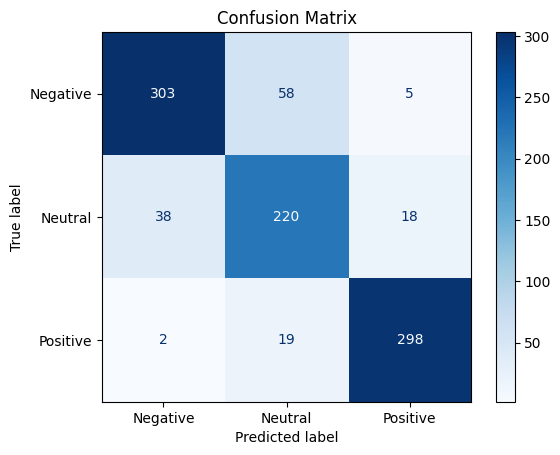

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix, ConfusionMatrixDisplay

# Plot training & validation metrics
# logs = pd.DataFrame(trainer.state.log_history)
# loss_logs = logs[['step', 'loss', 'eval_loss', 'eval_accuracy']].dropna()

# plt.figure(figsize=(12, 6))
# plt.plot(loss_logs['step'], loss_logs['loss'], label='Training Loss', marker='o')
# plt.plot(loss_logs['step'], loss_logs['eval_loss'], label='Validation Loss', marker='o')
# plt.plot(loss_logs['step'], loss_logs['eval_accuracy'], label='Validation Accuracy', marker='o')
# plt.xlabel('Training Steps')
# plt.ylabel('Value')
# plt.title('Training & Validation Loss and Accuracy')
# plt.legend()
# plt.grid(True)
# plt.show()

# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Neutral", "Positive"])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Save the model and tokenizer
# model.save_pretrained("sentiment-review-model-Dump-oversample")
# tokenizer.save_pretrained("sentiment-review-model-Dump-oversample")


('sentiment-review-model-Dump-oversample/tokenizer_config.json',
 'sentiment-review-model-Dump-oversample/special_tokens_map.json',
 'sentiment-review-model-Dump-oversample/vocab.txt',
 'sentiment-review-model-Dump-oversample/added_tokens.json',
 'sentiment-review-model-Dump-oversample/tokenizer.json')

In [ ]:
!zip -r resultsDump-oversample.zip results/
from google.colab import files
files.download("resultsDump-oversample.zip")


updating: results/ (stored 0%)
updating: results/checkpoint-2072/ (stored 0%)
updating: results/checkpoint-2072/scheduler.pt (deflated 57%)
updating: results/checkpoint-2072/config.json (deflated 51%)
updating: results/checkpoint-2072/optimizer.pt (deflated 25%)
updating: results/checkpoint-2072/tokenizer_config.json (deflated 75%)
updating: results/checkpoint-2072/trainer_state.json (deflated 73%)
updating: results/checkpoint-2072/training_args.bin (deflated 51%)
updating: results/checkpoint-2072/special_tokens_map.json (deflated 42%)
updating: results/checkpoint-2072/tokenizer.json (deflated 71%)
updating: results/checkpoint-2072/model.safetensors (deflated 7%)
updating: results/checkpoint-2072/rng_state.pth (deflated 25%)
updating: results/checkpoint-2072/vocab.txt (deflated 53%)
updating: results/checkpoint-1813/ (stored 0%)
updating: results/checkpoint-1813/scheduler.pt (deflated 56%)
updating: results/checkpoint-1813/config.json (deflated 51%)
updating: results/checkpoint-1813/op

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>